# MI = Mutual Information 
### Note : Higher the MI more the feature is useful, less MI = redundant feature

In [14]:
import pandas as pd

In [16]:
df = pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')

In [18]:
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [20]:
x = df.drop('Wine',axis=1)

In [22]:
y = df['Wine']

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [32]:
x_train.shape

(124, 13)

In [34]:
x_test.shape

(54, 13)

In [39]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(x_train, y_train)
mutual_info

array([0.41851399, 0.3099578 , 0.14442532, 0.23554323, 0.15199492,
       0.4674636 , 0.71927135, 0.12280232, 0.25601279, 0.61909971,
       0.56625633, 0.54136626, 0.54117783])

In [41]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = x_train.columns
mutual_info.sort_values(ascending=False)

Flavanoids              0.719271
Color.int               0.619100
Hue                     0.566256
OD                      0.541366
Proline                 0.541178
Phenols                 0.467464
Alcohol                 0.418514
Malic.acid              0.309958
Proanth                 0.256013
Acl                     0.235543
Mg                      0.151995
Ash                     0.144425
Nonflavanoid.phenols    0.122802
dtype: float64

<Axes: >

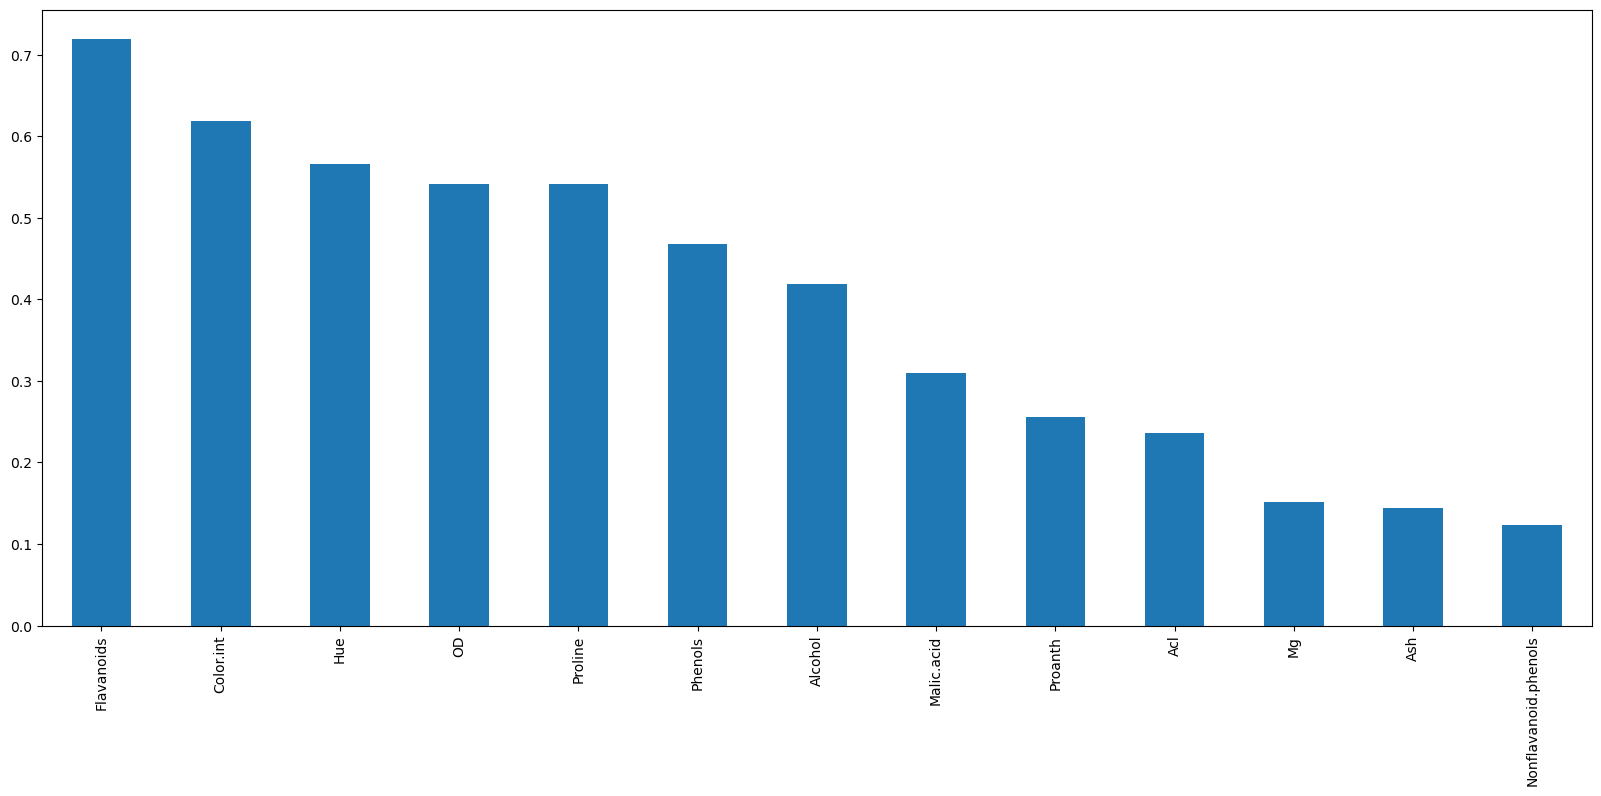

In [43]:
# let's plot the ordered mutual_info values per feature
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8))

In [45]:
from sklearn.feature_selection import SelectKBest

In [49]:
#No we Will select the top 5 important features
sel_five_cols = SelectKBest(mutual_info_classif, k=5)
sel_five_cols.fit(x_train.fillna(0), y_train)
x_train.columns[sel_five_cols.get_support()]

Index(['Flavanoids', 'Color.int', 'Hue', 'OD', 'Proline'], dtype='object')